In [1]:
from typing import Union

import numpy as np
import tqdm.notebook as tqdm
from matplotlib import pyplot as plt

from tdc.single_pred import ADME
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Draw, rdFingerprintGenerator
from rdkit.Chem.Draw import SimilarityMaps

# Quiet rdkit warnings
RDLogger.logger().setLevel(RDLogger.CRITICAL)

import torch
from torch import nn, optim
from torch.nn import Module, Sequential, ModuleList

import bcos
from bcos.modules import BcosLinear
from bcos.modules.norms import DetachableLayerNorm

In [2]:
class BCosMLP(Module):
    def __init__(
        self,
        input_size: int,
        output_size: int,
        hidden_size: int,
        num_layers: int,
        b: Union[int, float] = 2,
        max_out: int = 1,
        *args,
        **kwargs
    ):
        super().__init__(*args, **kwargs)
        self.bcoss = ModuleList([
            BcosLinear(dim_in, dim_out, b=b, max_out=max_out) for dim_in, dim_out in zip(
                [input_size] + [hidden_size] * num_layers,
                [hidden_size] * num_layers + [output_size])
        ])
        self.norms = ModuleList([DetachableLayerNorm(s) for s in [input_size] + [hidden_size] * num_layers])

    def forward(self, x):
        for bcos, norm in zip(self.bcoss, self.norms):
            x = norm(x)
            x = bcos(x)
        return x

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.stack = nn.Sequential(
            nn.Linear(1024, 1024),
            nn.GELU(),
            nn.Linear(1024, 1024),
            nn.GELU(),
            nn.Linear(1024, 1)
        )

    def forward(self, x):
        return self.stack(x)

In [4]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
smiles2fp = lambda smiles: fpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smiles))

In [6]:
data = ADME(name = 'Solubility_AqSolDB')
split = data.get_split(method='random')

Found local copy...
Loading...
Done!


In [7]:
device='cpu'

In [31]:
import tqdm
from torch.utils.data import Dataset, DataLoader

class SolubilityDataset(Dataset):
    def __init__(self, split, y_norm=None):
        self.fingerprints = torch.tensor(list(map(smiles2fp, split['Drug'])), dtype=torch.float).to(device)
        self.labels = torch.tensor(split['Y'], dtype=torch.float).to(device)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        fingerprint = self.fingerprints[idx]
        label = self.labels[idx]
        return fingerprint, label

train_dataset = SolubilityDataset(split['train'])
valid_dataset = SolubilityDataset(split['valid'])
test_dataset = SolubilityDataset(split['test'])

mean = train_dataset.labels.mean()
var = train_dataset.labels.std()
train_dataset.labels = (train_dataset.labels - mean) / var
valid_dataset.labels = (valid_dataset.labels - mean) / var
test_dataset.labels = (test_dataset.labels - mean) / var

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32)
test_dataloader = DataLoader(test_dataset, batch_size=32)

In [32]:
def train_step(model, loader):
    model.train()
    total_loss = 0
    for fingerprints, labels in train_dataloader:
        optimizer.zero_grad()
        outputs = model(fingerprints)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
    return total_loss / len(loader.dataset)

def test_step(model, loader):
    model.eval()
    valid_loss = 0.0
    with torch.no_grad():
        for fingerprints, labels in valid_dataloader:
            outputs = model(fingerprints)
            valid_loss += criterion(outputs.squeeze(), labels).item()
    valid_loss /= len(valid_dataloader)
    return valid_loss

## B-Cos MLP

In [33]:
model = BCosMLP(1024, 1, 256, 1, b=2, max_out=2)
model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50
train_losses, valid_losses = list(), list()
for epoch in range(num_epochs):
    train_loss = train_step(model, train_dataloader)
    valid_loss = test_step(model, valid_dataloader)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f'Epoch: {epoch + 1:03d}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch: 001, Train Loss: 0.5342, Validation Loss: 0.4268
Epoch: 002, Train Loss: 0.2935, Validation Loss: 0.3746
Epoch: 003, Train Loss: 0.2121, Validation Loss: 0.3592
Epoch: 004, Train Loss: 0.1671, Validation Loss: 0.3568
Epoch: 005, Train Loss: 0.1399, Validation Loss: 0.3582
Epoch: 006, Train Loss: 0.1208, Validation Loss: 0.3445
Epoch: 007, Train Loss: 0.1039, Validation Loss: 0.3546
Epoch: 008, Train Loss: 0.0949, Validation Loss: 0.3452
Epoch: 009, Train Loss: 0.0822, Validation Loss: 0.3350
Epoch: 010, Train Loss: 0.0760, Validation Loss: 0.3491
Epoch: 011, Train Loss: 0.0685, Validation Loss: 0.3408
Epoch: 012, Train Loss: 0.0643, Validation Loss: 0.3446
Epoch: 013, Train Loss: 0.0628, Validation Loss: 0.3363
Epoch: 014, Train Loss: 0.0587, Validation Loss: 0.3412
Epoch: 015, Train Loss: 0.0544, Validation Loss: 0.3302
Epoch: 016, Train Loss: 0.0551, Validation Loss: 0.3476
Epoch: 017, Train Loss: 0.0518, Validation Loss: 0.3312
Epoch: 018, Train Loss: 0.0499, Validation Loss:

Text(0, 0.5, 'loss')

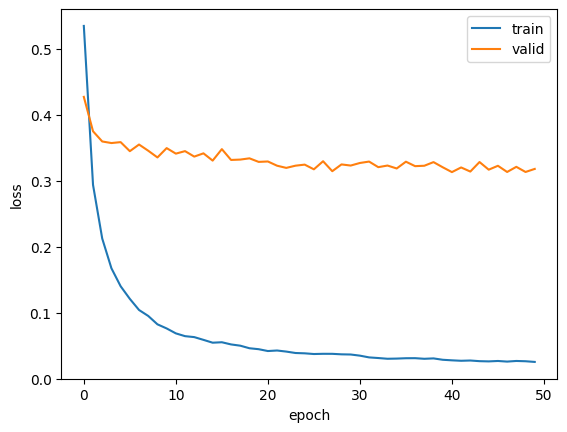

In [34]:
plt.plot(train_losses, label='train')
plt.plot(valid_losses, label='valid')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')

In [35]:
model.eval()
test_loss = 0.0
with torch.no_grad():
    for fingerprints, labels in test_dataloader:
        outputs = model(fingerprints)
        test_loss += criterion(outputs.squeeze(), labels).item()
test_loss /= len(test_dataloader)
print(f'Test Loss: {test_loss:.4f}')

Test Loss: 0.2967


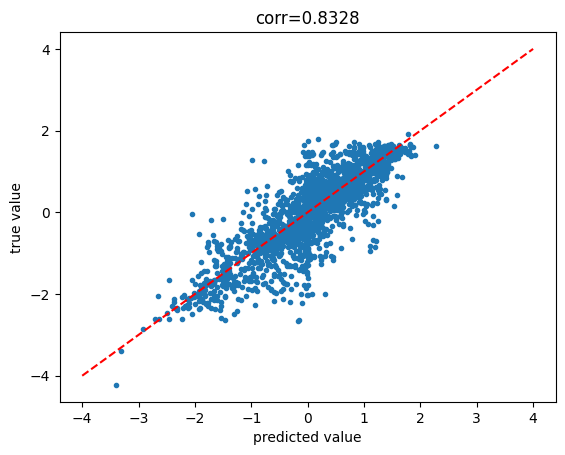

In [37]:
with torch.no_grad():
  predictions, ground_truth = list(), list()
  for data, y in test_dataloader:
      outputs = model(data)
      predictions.extend(list(outputs.squeeze().cpu()))
      ground_truth.extend(list(y.cpu()))
plt.scatter(predictions, ground_truth, marker='.')
plt.ylabel('true value')
plt.xlabel('predicted value')
plt.title(f'corr={np.corrcoef(predictions, ground_truth)[1,0]:.4f}')
plt.plot([-4, 4], [-4, 4], 'r--');

In [38]:
def explain(model, smiles):
    fp = torch.tensor(smiles2fp(row['Drug']), dtype=torch.float).to(device)
    with torch.enable_grad(), bcos.explanation_mode(model):
        input_x = fp.clone().requires_grad_()
        out = model(input_x)
        pred = out[0]
        pred.backward(inputs=[input_x])
    
        return {
            "explanation": input_x * input_x.grad,
            "pred": pred,
            "data": input_x,
        }

In [39]:
def viz_explanation(mol, result):
    atom_attr = [0] * mol.GetNumAtoms()
    
    ao = AllChem.AdditionalOutput()
    ao.CollectBitInfoMap()
    fp = fpgen.GetFingerprint(mol, additionalOutput=ao)
    
    for bit, flippers in ao.GetBitInfoMap().items():
        for loc, radius in flippers:  # wir sagen dankeschön...
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, loc)
            for idx in env:
                bond = mol.GetBondWithIdx(idx)
                for idx in [bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()]:
                    atom_attr[idx] += result['explanation'][bit].item()
    
    return SimilarityMaps.GetSimilarityMapFromWeights(mol, atom_attr)

0.12057296186685562 0.09253270924091339 -2.2839


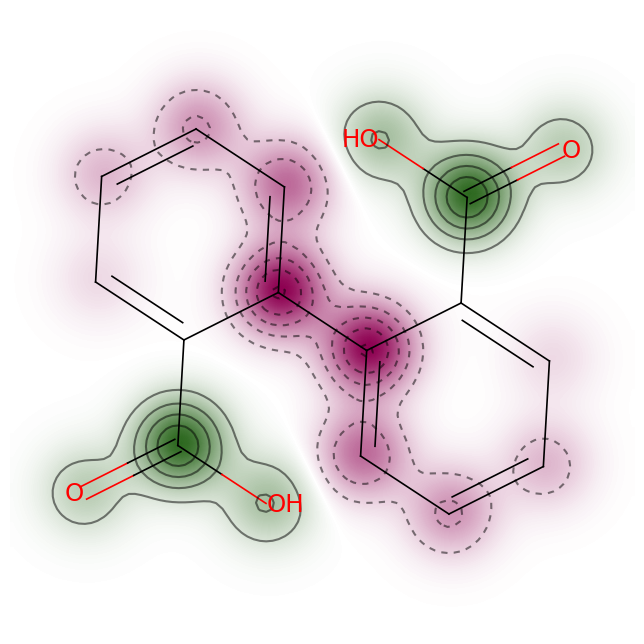

In [52]:
idx = 2
row = split['test'].iloc[idx]
result = explain(model, row.Drug)
print(result['explanation'].sum().item(), result['pred'].item(), row.Y)
viz_explanation(Chem.MolFromSmiles(row.Drug), result);

## Baseline RF

In [54]:
from sklearn.ensemble import RandomForestRegressor

In [55]:
X_train = train_dataset.fingerprints.detach().numpy()
y_train = train_dataset.labels.detach().numpy()
X_test = test_dataset.fingerprints.detach().numpy()
y_test = test_dataset.labels.detach().numpy()

In [61]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [62]:
rf.feature_importances_

array([0.0002384 , 0.00334488, 0.00335447, ..., 0.00019411, 0.00064143,
       0.00044966])

In [70]:
def explain_rf(model, smiles):
    input_x = smiles2fp(row['Drug'])
    return {
        "explanation": input_x * model.feature_importances_,
        "pred": model.predict(input_x.reshape(1, -1)),
        "data": input_x,
    }

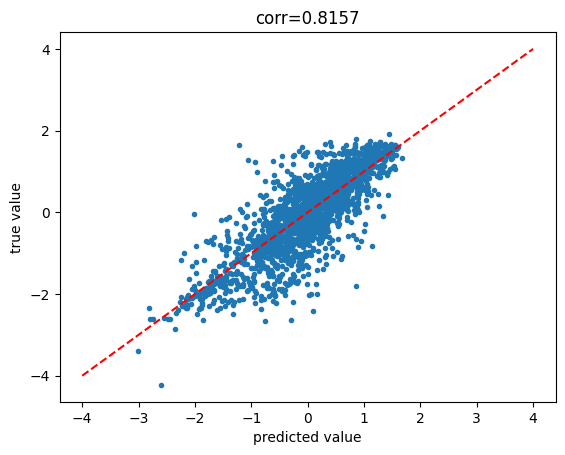

In [72]:
predictions = rf.predict(X_test)
plt.scatter(predictions, y_test, marker='.')
plt.ylabel('true value')
plt.xlabel('predicted value')
plt.title(f'corr={np.corrcoef(predictions, y_test)[1,0]:.4f}')
plt.plot([-4, 4], [-4, 4], 'r--');

0.14074661841055738 [0.07235661] -2.2839


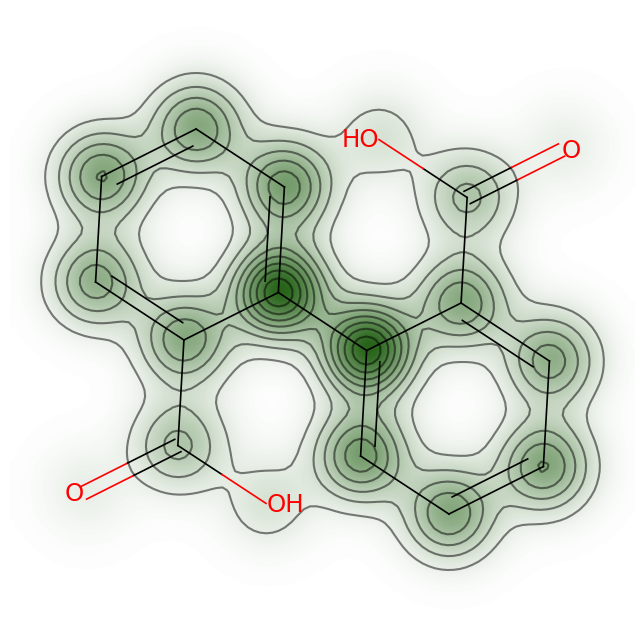

In [73]:
idx = 2
row = split['test'].iloc[idx]
result = explain_rf(rf, row.Drug)
print(result['explanation'].sum(), result['pred'], row.Y)
viz_explanation(Chem.MolFromSmiles(row.Drug), result);

## Baseline MLP

In [53]:
model = MLP()
model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50
train_losses, valid_losses = list(), list()
for epoch in range(num_epochs):
    train_loss = train_step(model, train_dataloader)
    valid_loss = test_step(model, valid_dataloader)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f'Epoch: {epoch + 1:03d}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch: 001, Train Loss: 0.5031, Validation Loss: 0.3863
Epoch: 002, Train Loss: 0.3672, Validation Loss: 0.4347
Epoch: 003, Train Loss: 0.3195, Validation Loss: 0.3550
Epoch: 004, Train Loss: 0.2736, Validation Loss: 0.3827
Epoch: 005, Train Loss: 0.2362, Validation Loss: 0.3935
Epoch: 006, Train Loss: 0.2041, Validation Loss: 0.3646
Epoch: 007, Train Loss: 0.1747, Validation Loss: 0.3502
Epoch: 008, Train Loss: 0.1473, Validation Loss: 0.3475
Epoch: 009, Train Loss: 0.1237, Validation Loss: 0.3576
Epoch: 010, Train Loss: 0.1057, Validation Loss: 0.3596
Epoch: 011, Train Loss: 0.0905, Validation Loss: 0.3471
Epoch: 012, Train Loss: 0.0837, Validation Loss: 0.3562
Epoch: 013, Train Loss: 0.0711, Validation Loss: 0.3755
Epoch: 014, Train Loss: 0.0638, Validation Loss: 0.3461
Epoch: 015, Train Loss: 0.0576, Validation Loss: 0.3807
Epoch: 016, Train Loss: 0.0540, Validation Loss: 0.3621
Epoch: 017, Train Loss: 0.0514, Validation Loss: 0.3457
Epoch: 018, Train Loss: 0.0454, Validation Loss:

Text(0, 0.5, 'loss')

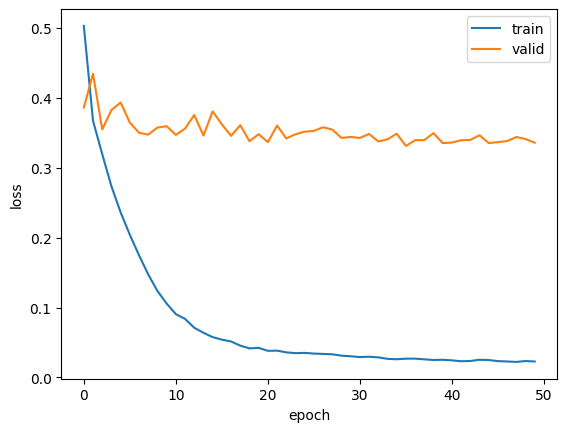

In [56]:
plt.plot(train_losses, label='train')
plt.plot(valid_losses, label='valid')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')

In [57]:
model.eval()
test_loss = 0.0
with torch.no_grad():
    for fingerprints, labels in test_dataloader:
        outputs = model(fingerprints)
        test_loss += criterion(outputs.squeeze(), labels).item()
test_loss /= len(test_dataloader)
print(f'Test Loss: {test_loss:.4f}')

Test Loss: 0.3075


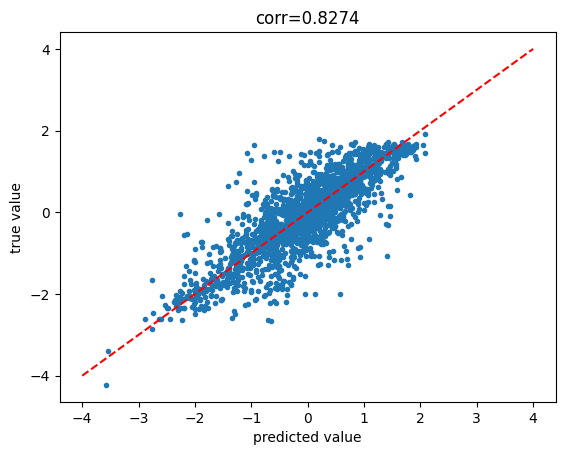

In [59]:
with torch.no_grad():
  predictions, ground_truth = list(), list()
  for data, y in test_dataloader:
      outputs = model(data)
      predictions.extend(list(outputs.squeeze().cpu()))
      ground_truth.extend(list(y.cpu()))
plt.scatter(predictions, ground_truth, marker='.')
plt.ylabel('true value')
plt.xlabel('predicted value')
plt.title(f'corr={np.corrcoef(predictions, ground_truth)[1,0]:.4f}')
plt.plot([-4, 4], [-4, 4], 'r--');